# Ridge Residual Analysis

**Read-only diagnostic experiment.** Determines whether temporal structure remains in Prophet residuals after Ridge regression — and whether a nonlinear learner (GRU) is still justified.

> **Scope:** CSRLE B0-LC, 99 containers. Trains Ridge only. No GRU. No modification of prior experiments.

## 1. Experiment overview

In [1]:
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

# Point to latest RRA run (update timestamp if needed)
EXP_DIR = REPO_ROOT / 'experiments' / 'ridge_residual_analysis_2026-07-26_161500'
CONFIG_PATH = EXP_DIR / 'config' / 'ridge_residual_analysis_config.json'

with CONFIG_PATH.open() as fh:
    config = json.load(fh)

print('Experiment:', config['experiment_name'])
print('Timestamp:', config['timestamp'])
print('Condition:', config['primary_condition'])
print('Containers:', config['dataset']['n_containers'])

Experiment: ridge_residual_analysis
Timestamp: 2026-07-26_161500
Condition: b0_lc
Containers: 99


## 2. Load frozen artifacts

In [2]:
eval_df = pd.read_csv(EXP_DIR / 'tables' / 'ridge_evaluation_per_container.csv')
diag_df = pd.read_csv(EXP_DIR / 'diagnostics' / 'temporal_structure_per_container.csv')
with (EXP_DIR / 'diagnostics' / 'white_noise_comparison.json').open() as fh:
    white_noise = json.load(fh)
with (EXP_DIR / 'reports' / 'final_report.json').open() as fh:
    final_report = json.load(fh)
with (EXP_DIR / 'diagnostics' / 'case_study_containers.json').open() as fh:
    case_studies = json.load(fh)

eval_df.head()

,container_id,n_val,ridge_pearson_r,ridge_mae_scaled,ridge_rmse_scaled,prophet_mean,prophet_std,prophet_var,remaining_mean,remaining_std,remaining_var,remaining_std_ratio,var_reduction_fraction
0,c_10032,154,0.126223,0.144269,0.166138,-0.063926,0.110860,0.012290,-0.089200,0.140162,0.019645,1.264317,-0.598498
1,c_10034,154,0.202876,0.111968,0.140738,-0.040257,0.113730,0.012935,-0.037930,0.135530,0.018368,1.191681,-0.420103
2,c_10089,154,0.327328,0.096281,0.125564,0.025262,0.067449,0.004549,0.054118,0.113303,0.012838,1.679835,-1.821845
3,c_10132,153,0.100514,0.187536,0.240615,0.022115,0.191012,0.036486,-0.000671,0.240614,0.057895,1.259680,-0.586794
4,c_1016,154,0.170456,0.044905,0.060418,-0.002183,0.033803,0.001143,0.000865,0.060412,0.003650,1.787172,-2.193985


## 3. Train Ridge

Ridge is trained offline by `scripts/run_ridge_residual_analysis.py`. Load metadata below.

In [3]:
with (EXP_DIR / 'ridge' / 'training' / 'ridge_training_metadata.json').open() as fh:
    ridge_meta = json.load(fh)
with (EXP_DIR / 'ridge' / 'training' / 'residual_stats.json').open() as fh:
    res_stats = json.load(fh)

ridge_meta

{'alpha': 1.0,
 'input_window': 96,
 'forecast_horizon': 96,
 'internal_val_split': 'chronological_80_20',
 'n_sequences_total': 41650,
 'n_sequences_train': 33320,
 'n_features': 96,
 'res_mean': 2.104351548466549e-05,
 'res_std': 0.11042643193055177,
 'ridge_coef_norm': 1.3878479636771337,
 'ridge_intercept_mean': -0.0035518391181687497}

## 4. Evaluate Ridge

In [4]:
cohort = eval_df[['ridge_pearson_r', 'ridge_mae_scaled', 'remaining_std_ratio']].describe()
cohort

,ridge_pearson_r,ridge_mae_scaled,remaining_std_ratio
count,99.000000,99.000000,99.000000
mean,0.125104,0.140550,1.818262
std,0.180117,0.085737,2.414084
min,-0.434187,0.027022,0.873890
25%,0.016835,0.085440,1.264395
50%,0.126223,0.126999,1.378635
75%,0.229974,0.170366,1.640133
max,0.516215,0.511879,20.115765


## 5. Remaining residual analysis

In [5]:
eval_df[['container_id', 'prophet_mean', 'prophet_std', 'remaining_mean', 'remaining_std', 'remaining_std_ratio', 'var_reduction_fraction']].describe()

,prophet_mean,prophet_std,remaining_mean,remaining_std,remaining_std_ratio,var_reduction_fraction
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,0.012135,0.126211,0.028830,0.174260,1.818262,-8.075012
std,0.071779,0.086135,0.085659,0.102921,2.414084,47.914426
min,-0.423027,0.004470,-0.412119,0.030231,0.873890,-403.644002
25%,-0.009838,0.073280,-0.002884,0.108897,1.264395,-1.690060
50%,0.011870,0.109731,0.022711,0.149495,1.378635,-0.900634
75%,0.039027,0.151289,0.065012,0.199343,1.640133,-0.598695
max,0.225213,0.453777,0.289724,0.526727,20.115765,0.236316


## 6. Distribution analysis

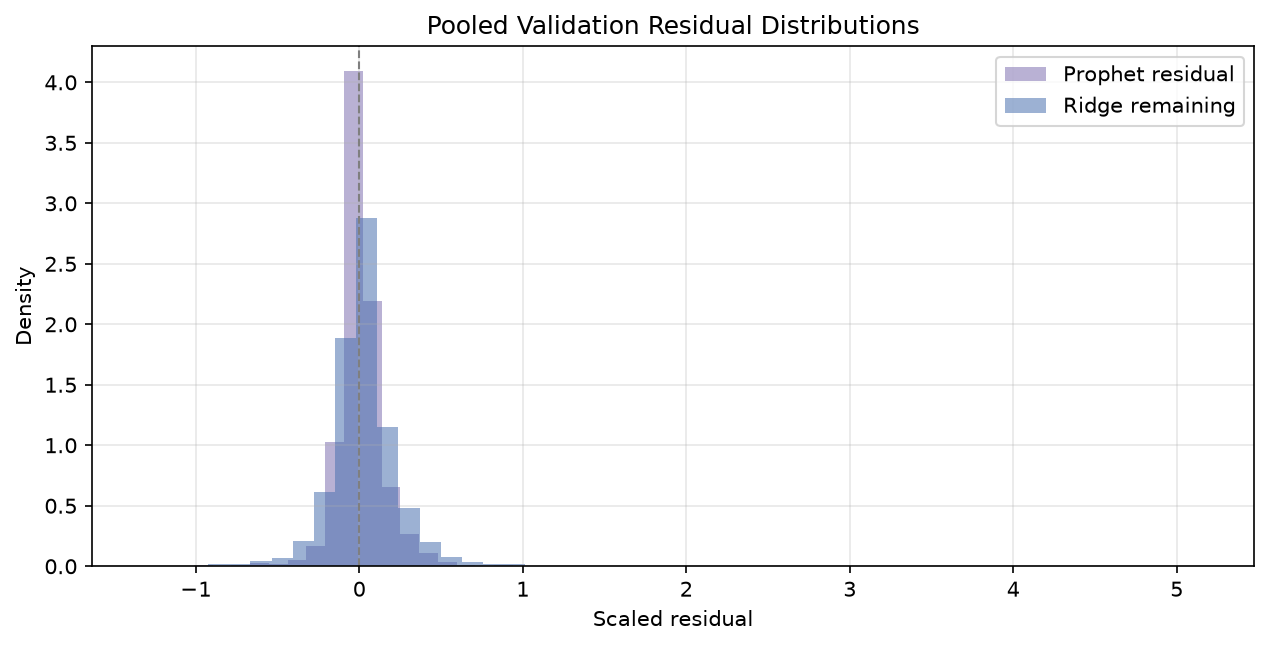

In [6]:
from IPython.display import Image
Image(filename=str(EXP_DIR / 'plots' / 'residual_distribution_comparison.png'))

## 7. ACF

Prophet mean |ACF| 1-10: 0.1994725373887009
Remaining mean |ACF| 1-10: 0.26603709002621445
Reduction: -0.06656455263751357


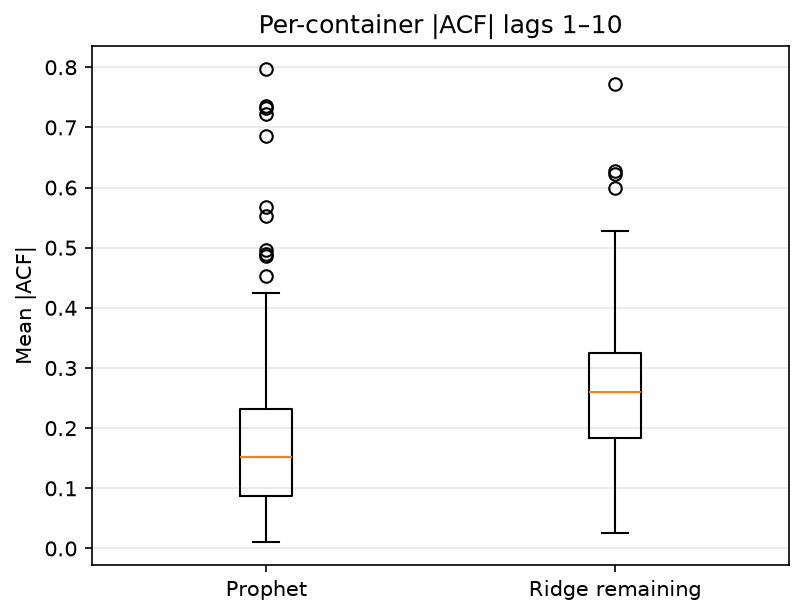

In [7]:
print('Prophet mean |ACF| 1-10:', white_noise['prophet_mean_avg_abs_acf_1_10'])
print('Remaining mean |ACF| 1-10:', white_noise['remaining_mean_avg_abs_acf_1_10'])
print('Reduction:', white_noise['mean_acf_reduction'])
Image(filename=str(EXP_DIR / 'plots' / 'acf_boxplot_comparison.png'))

## 8. PACF

Prophet mean |PACF| 1-10: 0.11012402073490532
Remaining mean |PACF| 1-10: 0.14132176576194033


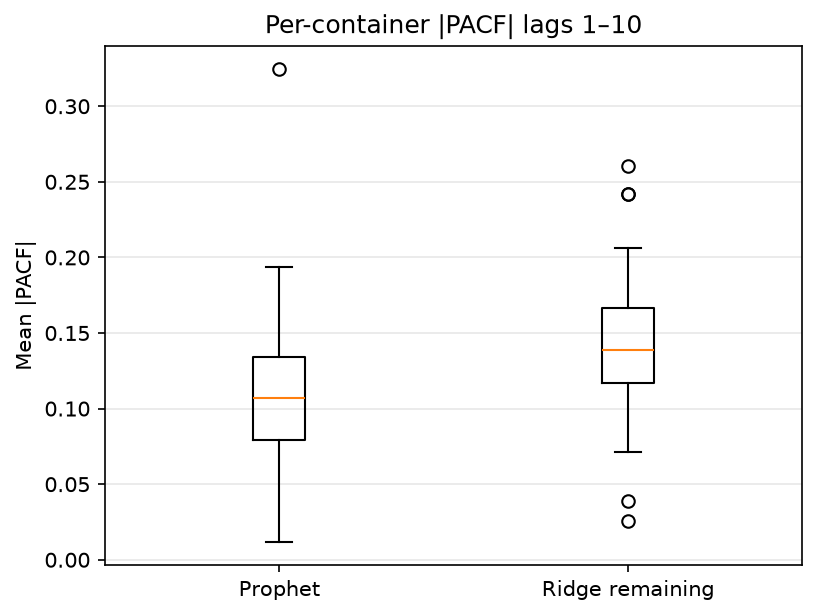

In [8]:
print('Prophet mean |PACF| 1-10:', white_noise['prophet_mean_avg_abs_pacf_1_10'])
print('Remaining mean |PACF| 1-10:', white_noise['remaining_mean_avg_abs_pacf_1_10'])
Image(filename=str(EXP_DIR / 'plots' / 'pacf_boxplot_comparison.png'))

## 9. Ljung–Box

In [9]:
print('Prophet reject fraction (lag 20):', white_noise['prophet_ljung_reject_fraction_lag_20'])
print('Remaining reject fraction (lag 20):', white_noise['remaining_ljung_reject_fraction_lag_20'])
diag_df[['container_id', 'prophet_lb_p_lag_20', 'remaining_lb_p_lag_20']].head()

Prophet reject fraction (lag 20): 0.7575757575757576
Remaining reject fraction (lag 20): 0.9595959595959596


,container_id,prophet_lb_p_lag_20,remaining_lb_p_lag_20
0,c_10032,1.694999e-105,8.540554e-35
1,c_10034,1.208065e-289,8.303328e-105
2,c_10089,3.596546e-06,1.758091e-49
3,c_10132,1.407507e-01,1.316265e-07
4,c_1016,2.517271e-02,9.273708e-66


## 10. FFT

In [10]:
fft_df = pd.read_csv(EXP_DIR / 'tables' / 'fft_summary.csv')
fft_df.describe()[['prophet_dominant_freq', 'remaining_dominant_freq']]

,prophet_dominant_freq,remaining_dominant_freq
count,99.000000,99.000000
mean,0.048299,0.054063
std,0.072494,0.048874
min,0.006494,0.006494
25%,0.012987,0.019804
50%,0.019481,0.058824
75%,0.059017,0.064935
max,0.500000,0.467532


## 11. White-noise comparison

In [11]:
white_noise

{'n_containers': 99,
 'prophet_mean_avg_abs_acf_1_10': 0.1994725373887009,
 'remaining_mean_avg_abs_acf_1_10': 0.26603709002621445,
 'prophet_mean_avg_abs_pacf_1_10': 0.11012402073490532,
 'remaining_mean_avg_abs_pacf_1_10': 0.14132176576194033,
 'mean_acf_reduction': -0.06656455263751357,
 'mean_pacf_reduction': -0.031197745027035022,
 'prophet_ljung_reject_fraction_lag_20': 0.7575757575757576,
 'remaining_ljung_reject_fraction_lag_20': 0.9595959595959596,
 'ljung_reject_reduction_lag_20': -0.202020202020202,
 'prophet_dominant_freq_mean': 0.04829906086449851,
 'remaining_dominant_freq_mean': 0.05406342428389524,
 'acf_bootstrap': {'mean_diff': -0.06656455263751357,
  'ci_low': -0.09115040721495983,
  'ci_high': -0.041132589326896375},
 'pacf_bootstrap': {'mean_diff': -0.031197745027035022,
  'ci_low': -0.0391531768745039,
  'ci_high': -0.023043217926314193},
 'prophet_ljung_reject_fraction': 0.7575757575757576,
 'remaining_ljung_reject_fraction': 0.9595959595959596}

## 12. Case studies

best: c_15179


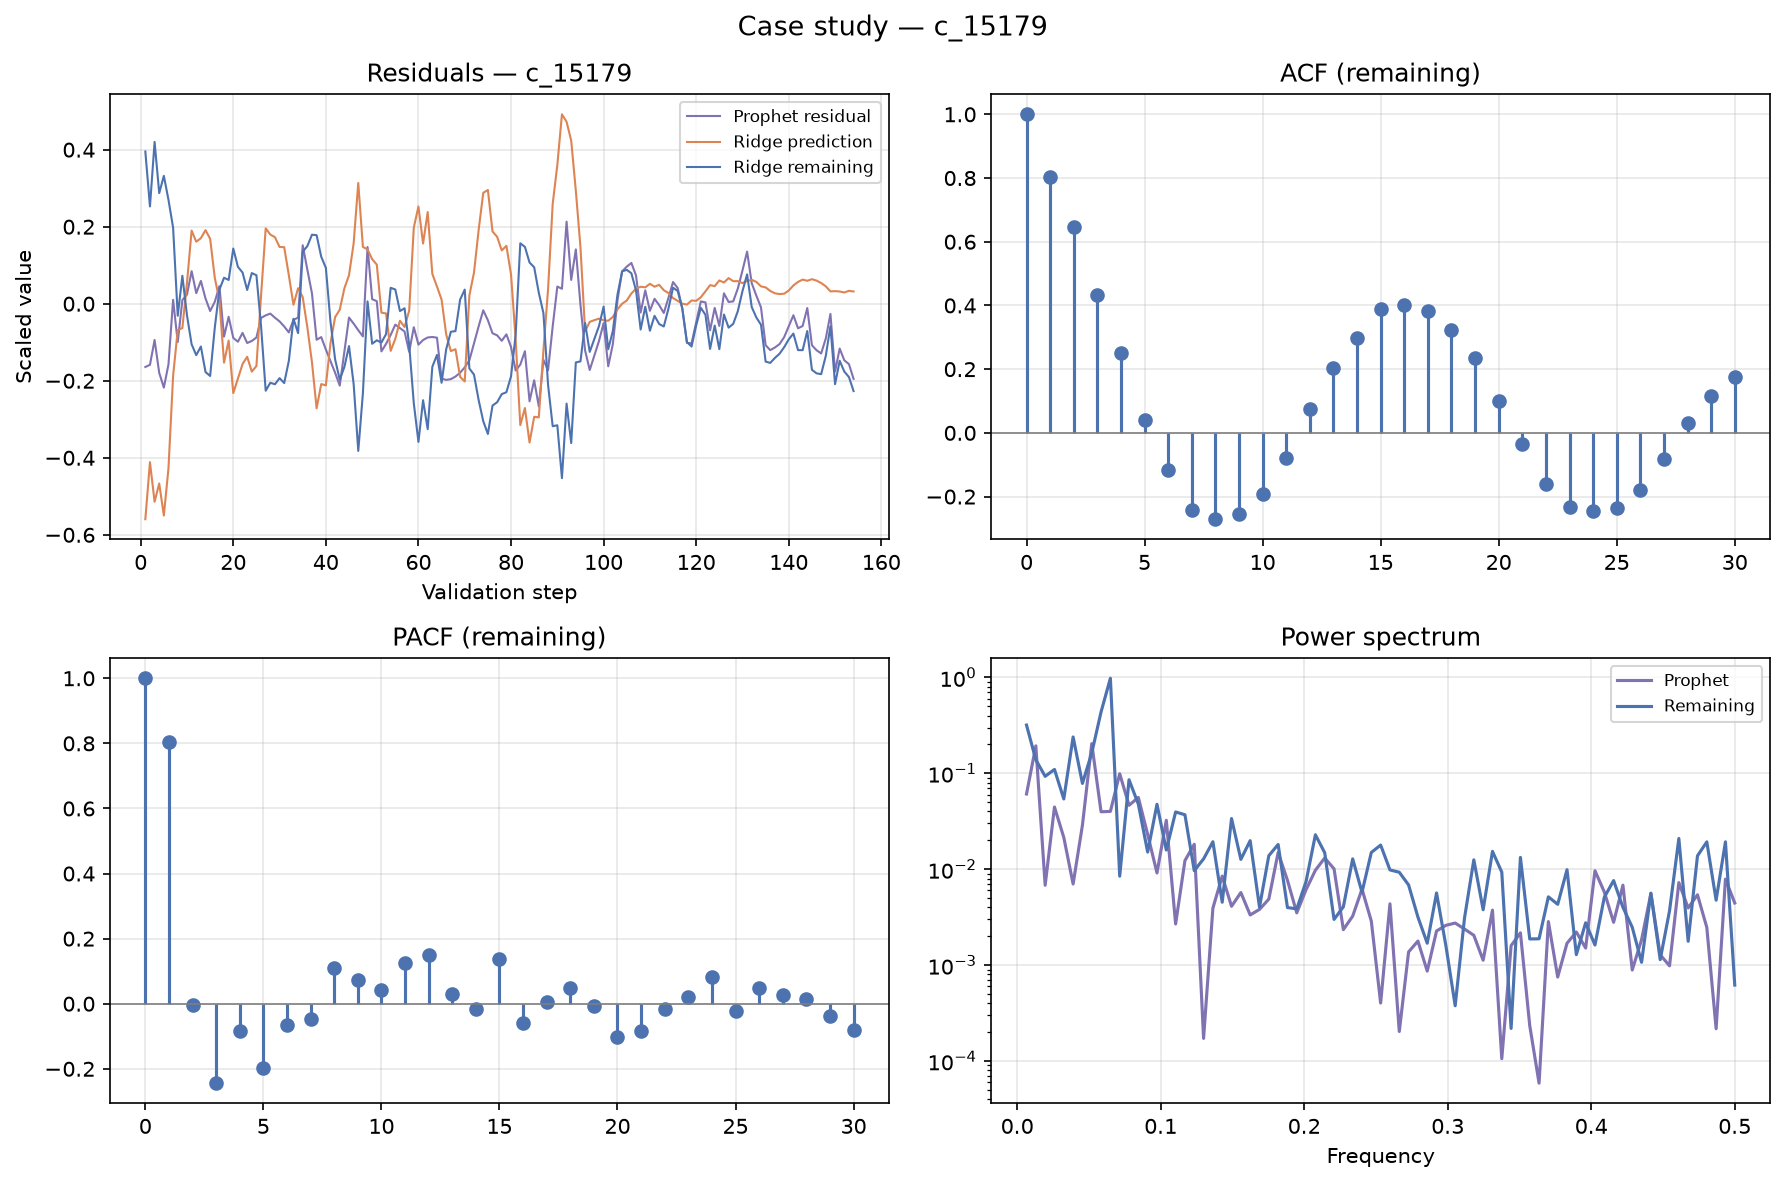

median: c_10032


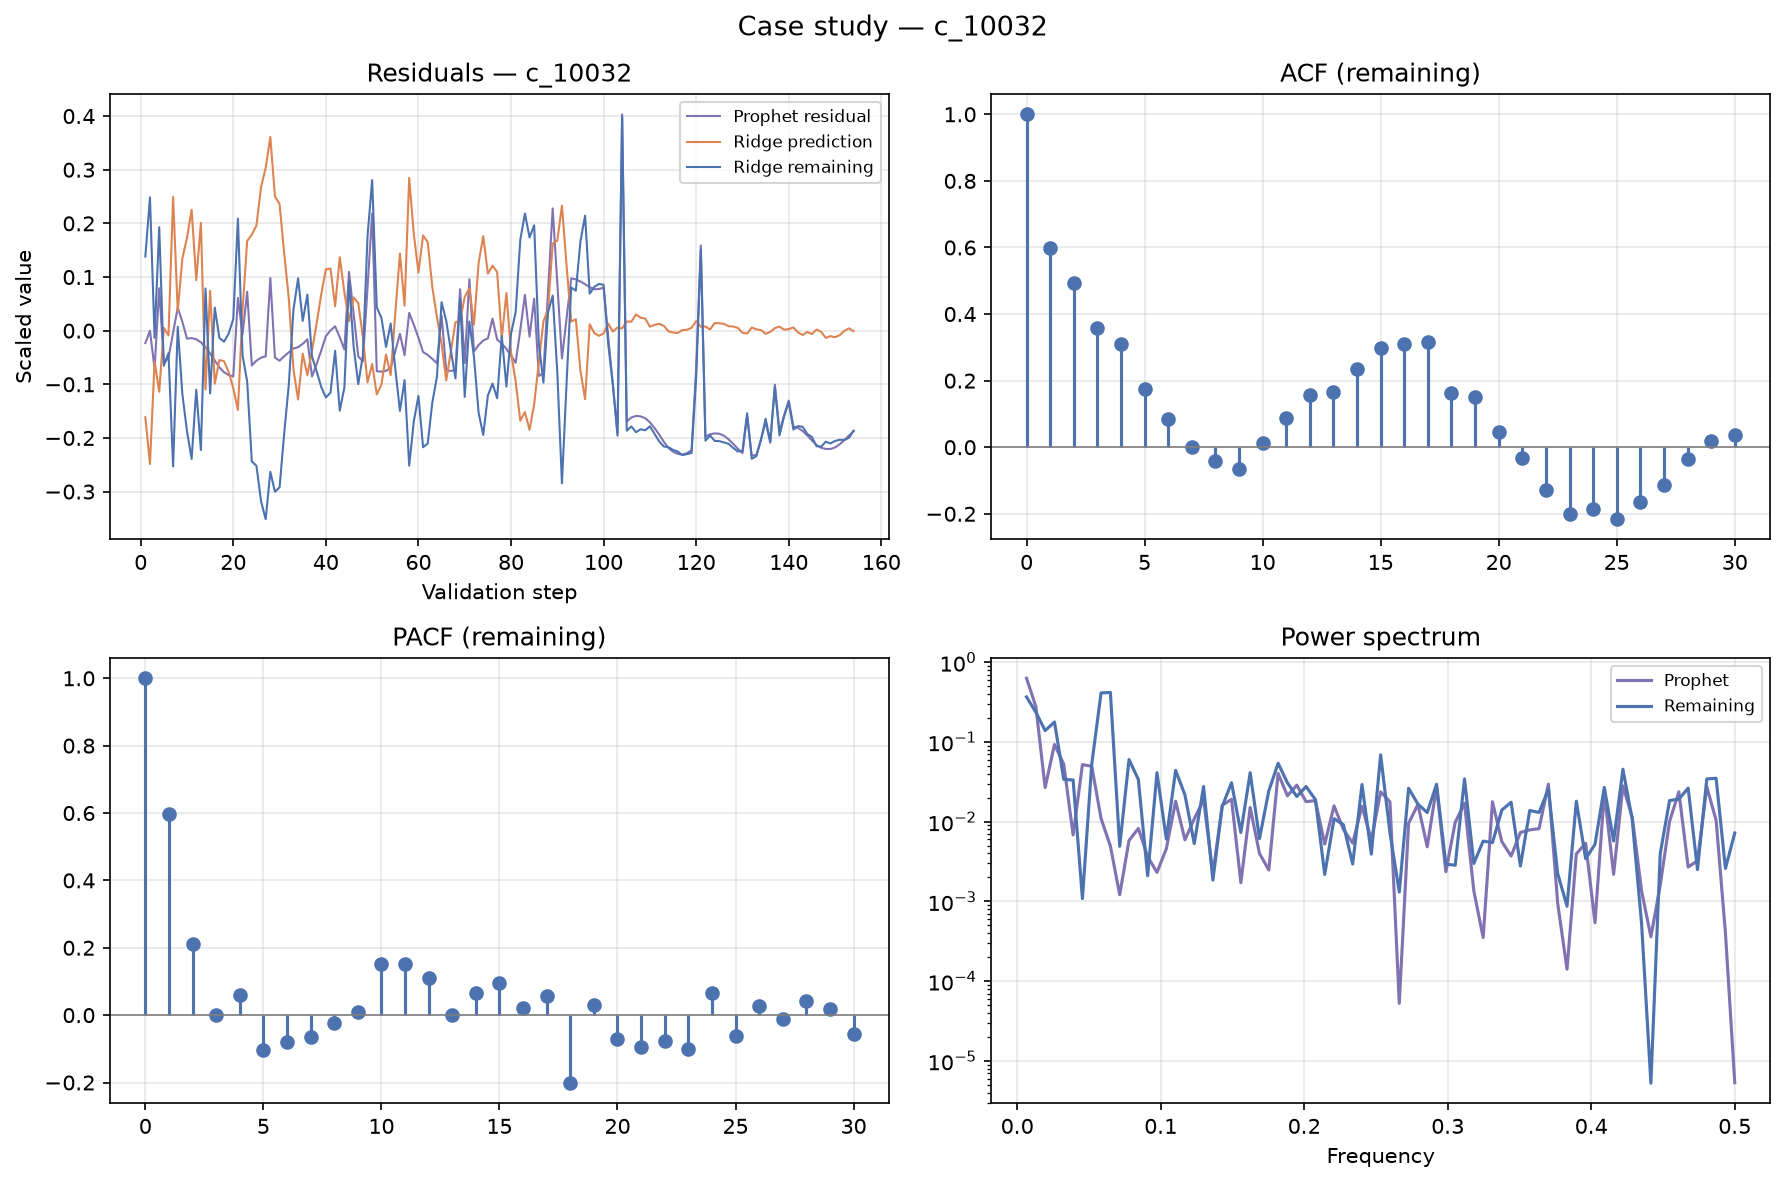

worst: c_12231


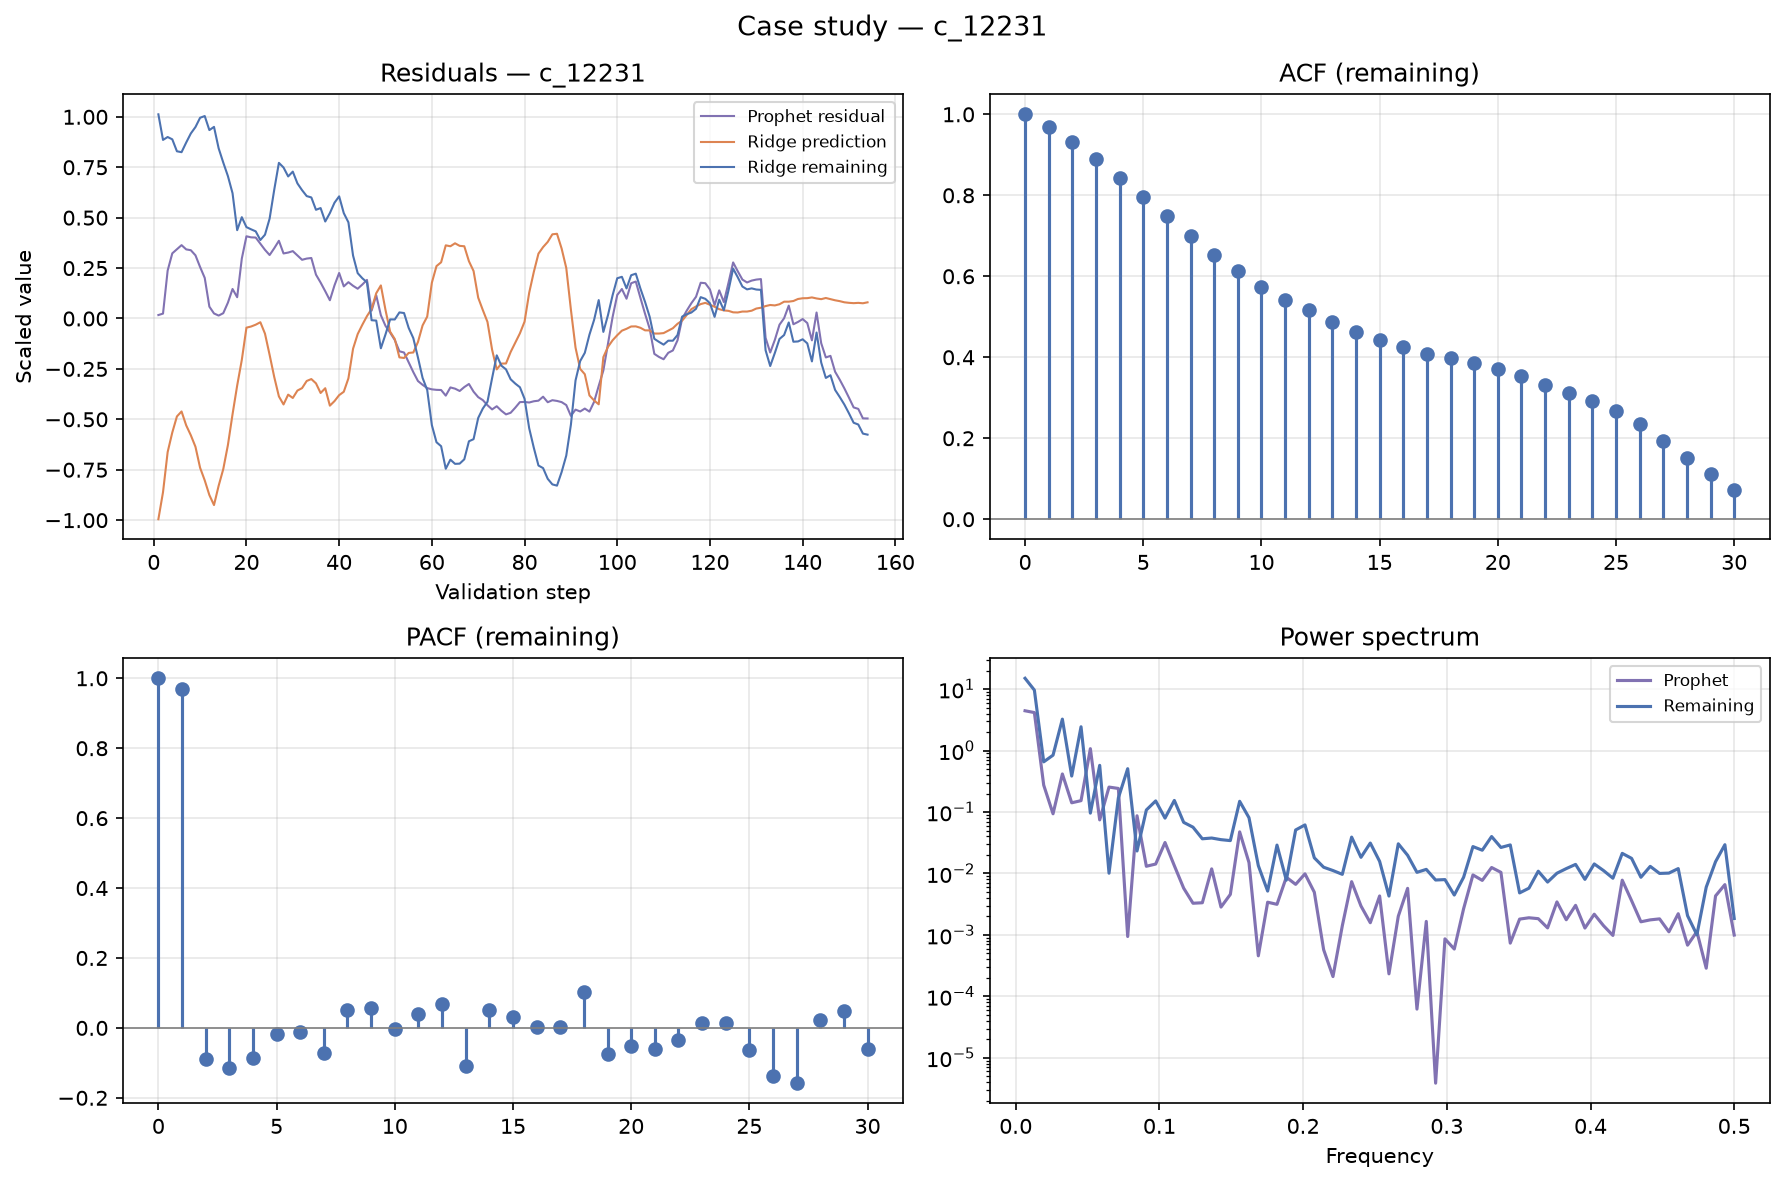

In [12]:
for label, cid in case_studies.items():
    print(f'{label}: {cid}')
    display(Image(filename=str(EXP_DIR / 'plots' / f'case_study_{label}_{cid}.png')))

## 13. Justification for Ridge→GRU

In [13]:
j = final_report['justification']
for k, v in j.items():
    print(f'{k}: {v}')

q1_ridge_removes_most_temporal_dependence: False
q2_ridge_residual_closer_to_white_noise: False
q3_remaining_still_rejects_white_noise: True
q4_remaining_still_significant_acf: True
q5_nonlinear_learner_justified: True
q6_ridge_gru_architecture_future_recommended: True
verdict: structure_persists_minimal_ridge_gain
prophet_mean_avg_abs_acf_1_10: 0.1994725373887009
remaining_mean_avg_abs_acf_1_10: 0.26603709002621445
prophet_ljung_reject_fraction_lag_20: 0.7575757575757576
remaining_ljung_reject_fraction_lag_20: 0.9595959595959596


## 14. Final conclusions

In [14]:
print('Verdict:', final_report['verdict'])
print()
for q, ans in final_report['explicit_answers'].items():
    print(q, '->', ans)

Verdict: structure_persists_minimal_ridge_gain

1_temporal_structure_removed_by_ridge -> {'acf_reduction': -0.06656455263751357, 'pacf_reduction': -0.031197745027035022, 'ljung_reject_reduction_lag_20': -0.202020202020202}
2_ridge_residual_closer_to_white_noise -> False
3_pct_containers_still_reject_white_noise -> 95.95959595959596
4_remaining_has_significant_temporal_dependence -> True
5_nonlinear_learner_justified -> True
6_ridge_gru_future_recommended -> True
